In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange

In [ ]:
1

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


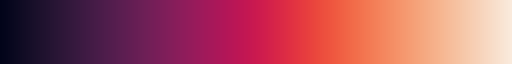

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

In [10]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]

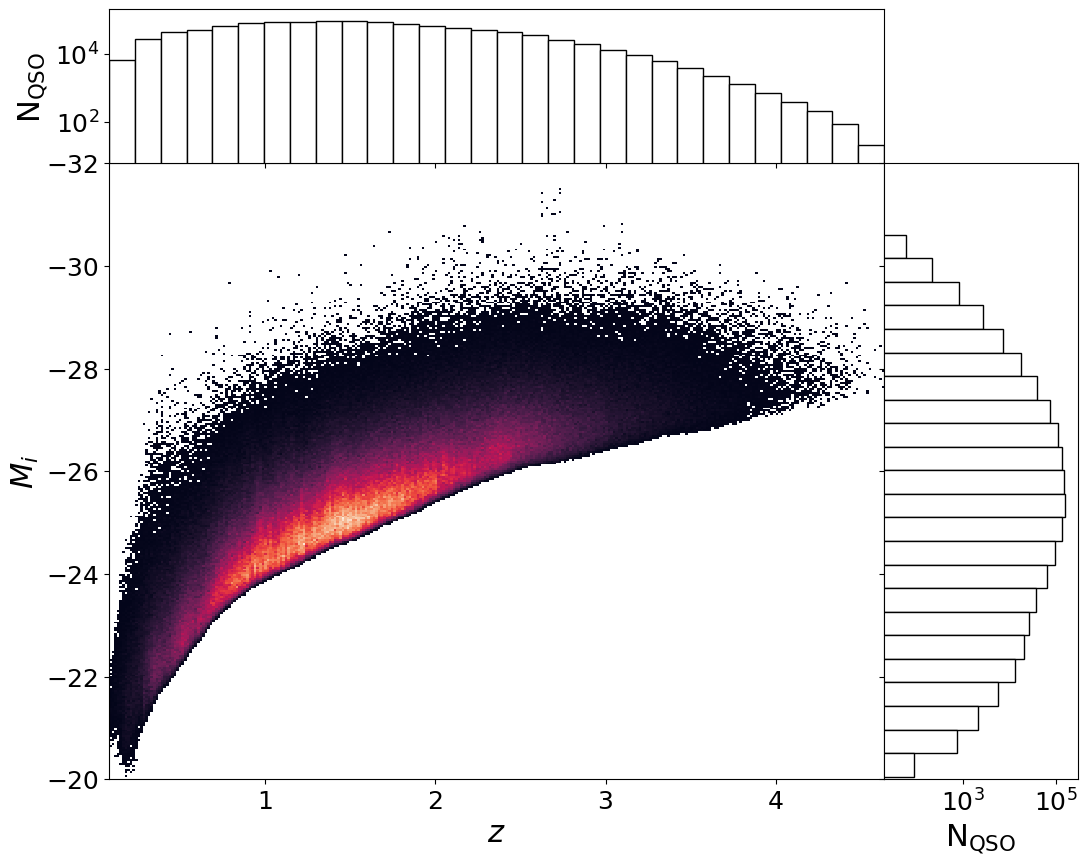

In [11]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in four z bins
## $\xi(s)$

In [12]:
# Create the bins array
rmin = 30 #0.1
rmax = 80 #180.0
nbins = 20 # 20 
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
# rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202

In [13]:
zbin_array = [0.0,1.0,2.0,3.0,4.0]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))

In [14]:
h = 0.674
Omega_m_planck20 = 0.315

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


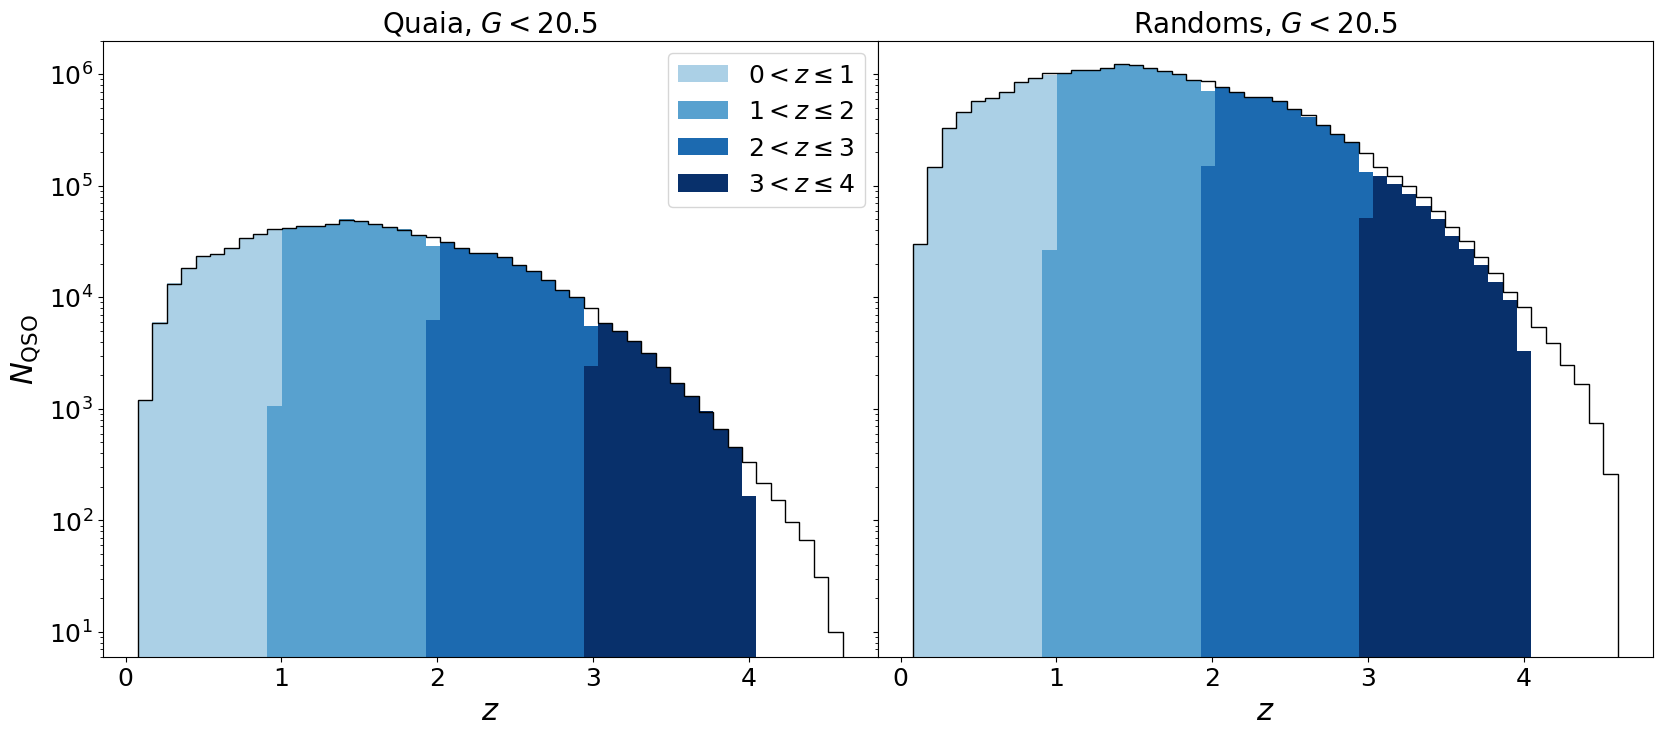

In [15]:
# plot data
bins = np.linspace(0.08, 4.6)
cf = []
fac_rand = 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
ax2 = fig.add_subplot(gs[1])

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)
ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')

for zbin in zbin_array[:-1]:
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)
    ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             bins = bins, color = cmap_blue[int(zbin)])
    ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
             bins = bins, color = cmap_blue[int(zbin)])

    cf.append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, h = h, Om0 = Omega_m_planck20))

ax1.set_xlabel('$z$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(6,2e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_yscale('log')
ax2.set_ylim(6,2e6)
ax2.set_title('Randoms, $G<{}$'.format(G_hi))
ax2.set_yticklabels([])
plt.show()

# Use delete-one jackknife resampling
## Split the sky into RA stripes

In [16]:
N = 25 #10
ra_bins = np.linspace(0, 360, N+1)
# N = len(ra_bins)
for i in range(N): #-1):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 14 15 16 17 18 19 20 21 22 23 24 25]
[ 1  2  3  4  5  6  7  8  9 10 11 12 1

## Compute $\xi(s)$ in each jackknife bin

In [17]:
cf_jackknife = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)

    for i in trange(N): #len(ra_bins)-1):
    
        jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
        jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

        cf_jackknife[zbin].append(quaia.xi_s(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, 
                                             nthreads = nthreads, rbins = rbins, h = h, Om0 = Omega_m_planck20))

G20.5_zmin0.0zmax1.0: 0.30              225792 vs 324336


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [08:54<00:00, 21.39s/it]


G20.5_zmin1.0zmax2.0: 0.28              467913 vs 648196


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [19:42<00:00, 47.30s/it]


G20.5_zmin2.0zmax3.0: 0.24              216828 vs 286508


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [08:56<00:00, 21.44s/it]


G20.5_zmin3.0zmax4.0: 0.21              28061 vs 35630


  0%|          | 0/25 [00:00<?, ?it/s]/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 25/25 [01:24<00:00,  3.38s/it]


## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[\xi^{(k)}\left(s_{i}\right)-\bar{\xi}\left(s_{i}\right)\right] \\
{\left[\xi^{(k)}\left(s_{j}\right)-\bar{\xi}\left(s_{j}\right)\right]}
\end{array}

In [18]:
C = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    cf_mean = np.nanmean(cf_jackknife[zbin], axis = 0)  # is it ok to ignore nan values?
    delta = cf_jackknife[zbin]-cf_mean
    C[zbin] = (N-1)/N*(delta.T @ delta)

## Retry on scales $10\geq s \geq 85h^{-1}$ Mpc

In [ ]:
# Create the bins array
rmin = 10 # 0.1 # start higher # 1.4 # 30
rmax = 85 # 200
nbins = 20 #90 #20
rbins_chi2 = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'
quaia.recenter(rbins_chi2)

In [ ]:
# plot data
cf = []

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

ax1 = fig.add_subplot(gs[0])
ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

# plot randoms  
ax2 = fig.add_subplot(gs[1])

# for comparison purposes
ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')

for zbin in zbin_array[:-1]:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)
    ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             bins = bins, color = cmap_blue[int(zbin)])
    ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(zbin),
             bins = bins, color = cmap_blue[int(zbin)])

    cf.append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins_chi2))

ax1.set_xlabel('$z$')
ax1.set_ylabel('$N_\mathrm{QSO}$')
ax1.set_yscale('log')
ax1.set_ylim(6,2e6)
ax1.set_title('Quaia, $G<{}$'.format(G_hi))
ax1.legend()

ax2.set_xlabel('$z$')
ax2.set_yscale('log')
ax2.set_ylim(6,2e6)
ax2.set_title('Randoms, $G<{}$'.format(G_hi))
ax2.set_yticklabels([])
plt.show()

In [ ]:
cf_jackknife = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, int(zbin),True, 'z', bins = zbin_array, 
                                                                                       tab_gcat_type = 'data', method = 'minmax', 
                                                                                    fac_rand = fac_rand, mask = mask*100, percentile = True)

    for i in range(len(ra_bins)-1):
    
        jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
        jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

        cf_jackknife[zbin].append(quaia.xi_s(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, 
                                             nthreads = nthreads, rbins = rbins_chi2))

In [ ]:
C = {zbin: [] for zbin in zbin_array[:-1]}
for zbin in zbin_array[:-1]:
    
    cf_mean = np.nanmean(cf_jackknife[zbin], axis = 0)  # is it ok to ignore nan values?
    delta = cf_jackknife[zbin]-cf_mean
    C[zbin] = (N-1)/N*(delta.T @ delta)

## Save the diagonal elements
### $\sigma_{\xi}\left(s_{i}\right)=\sqrt{C_{i i}}$

In [18]:
for zbin in zbin_array[:-1]:
    
    np.save('../results/sigma_xi_G{}_rmin{}_rmax{}_nbins{}_z{}'.format(G_hi, rmin, rmax, nbins, zbin), np.sqrt(np.diag(C[zbin])))

## Save the full covariance matrix

In [19]:
for zbin in zbin_array[:-1]:
    
    np.save('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}_planck20'.format(G_hi, rmin, rmax, nbins, zbin, N), C[zbin])

# Plot

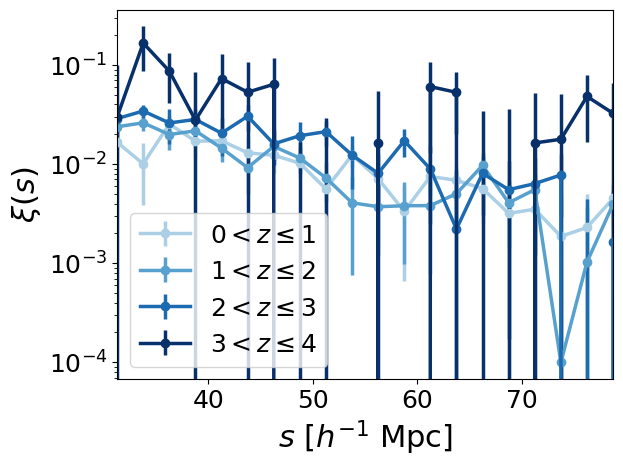

In [20]:
# plot!
r = quaia.recenter(rbins) #_chi2)
for zbin in zbin_array[:-1]:
    sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}_planck20.npy'.format(G_hi, rmin, rmax, nbins, zbin, N))))
    plt.errorbar(r, cf[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             linewidth = 2.5, color = cmap_blue[int(zbin)], yerr = sigma) #np.sqrt(np.diag(C[zbin])))
    plt.xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        plt.xscale('log')
    plt.yscale('log')
    plt.xlim(r[0], r[-1])
    # plt.ylim(4e-3, 5e1)
    plt.legend()
    plt.ylabel(r"$\xi(s)$")
plt.show()

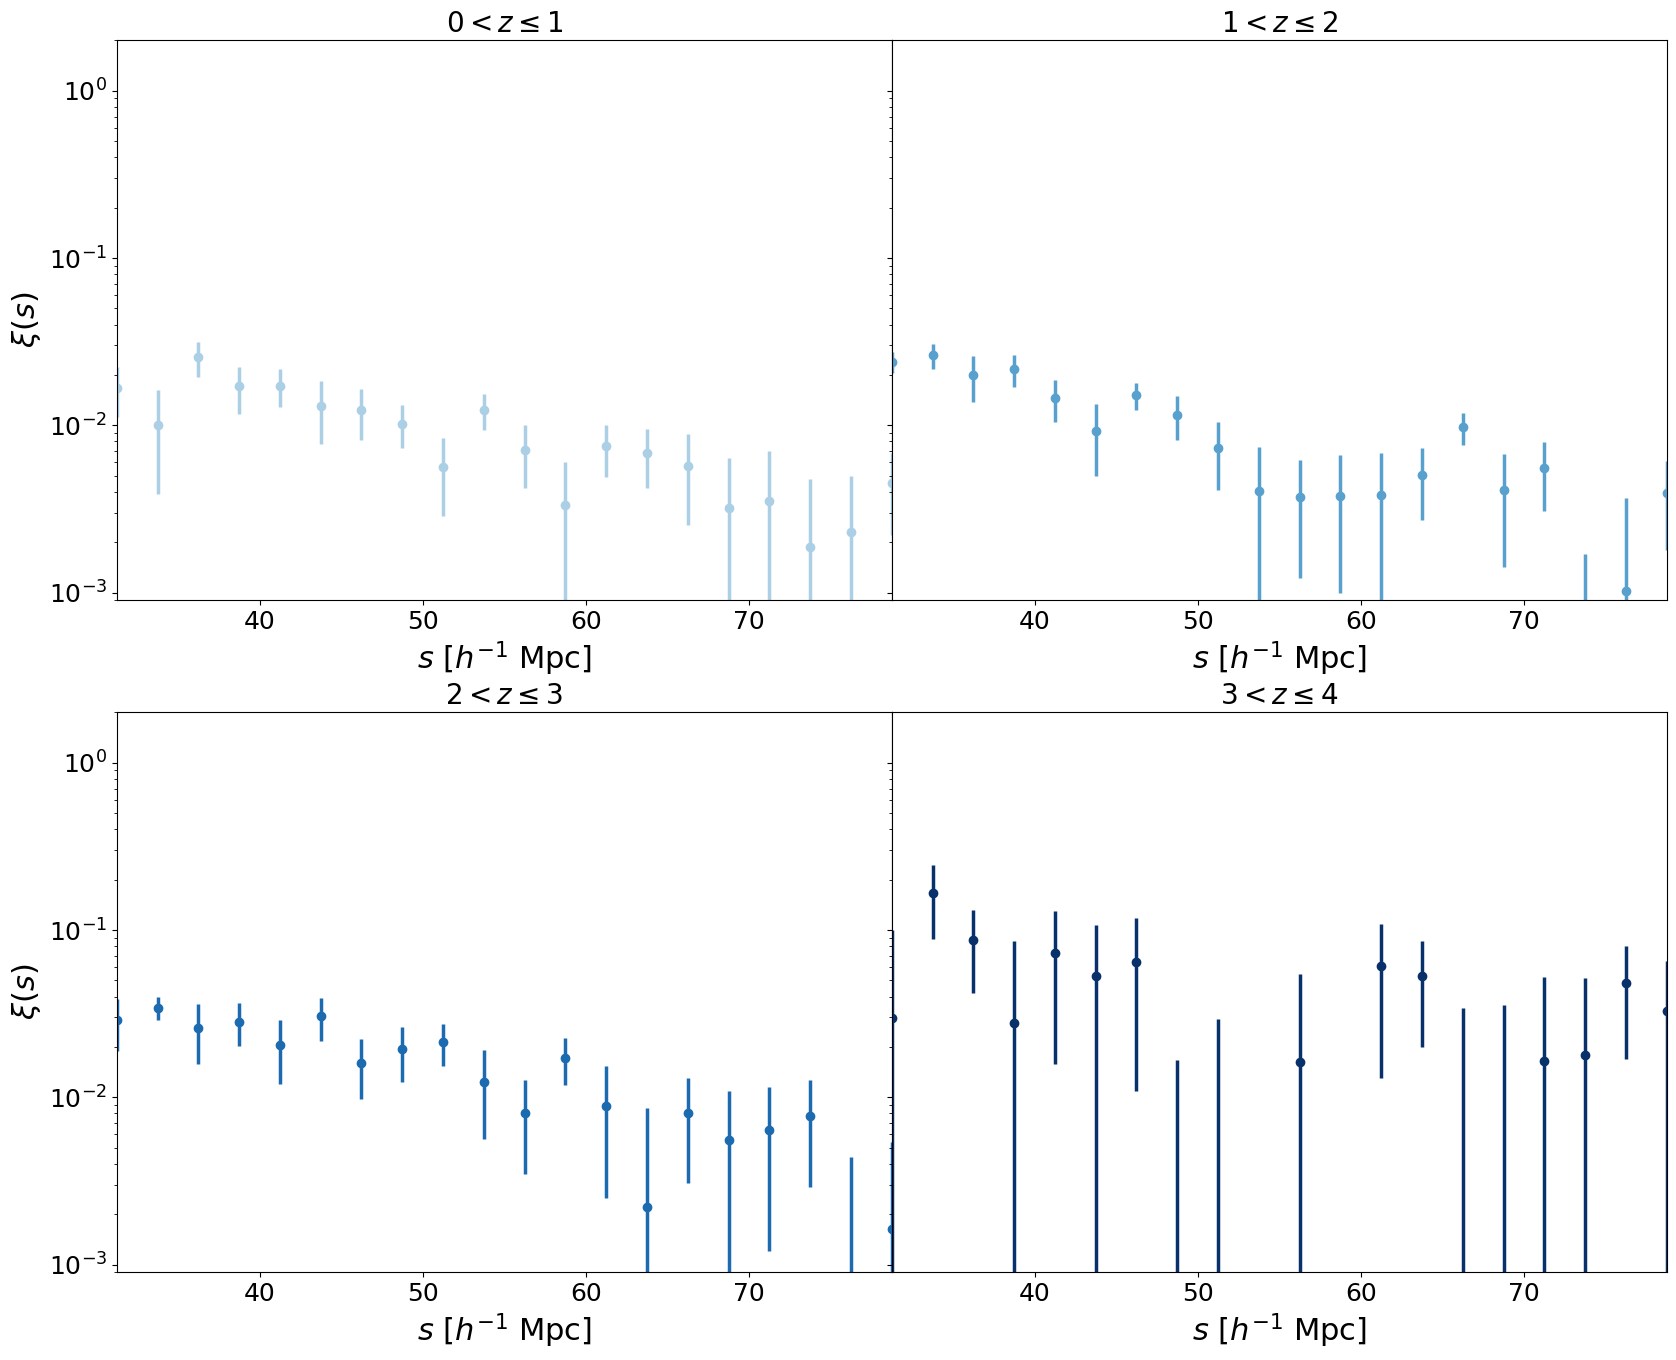

In [21]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.2)

for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}_planck20.npy'.format(G_hi, rmin, rmax, nbins, zbin, N))))    
    ax1.errorbar(r, cf[int(zbin)], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1), 
             linewidth = 2.5, color = cmap_blue[int(zbin)], yerr = sigma, linestyle = 'None')
        
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(r[0], r[-1])
    ax1.set_ylim(9e-4, 2)
    # if zbin>1:
    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    # else:
    #     ax1.set_xticklabels([])
    if zbin%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])
    # ax1.legend()

plt.show()

## Plot correlation matrix

(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)


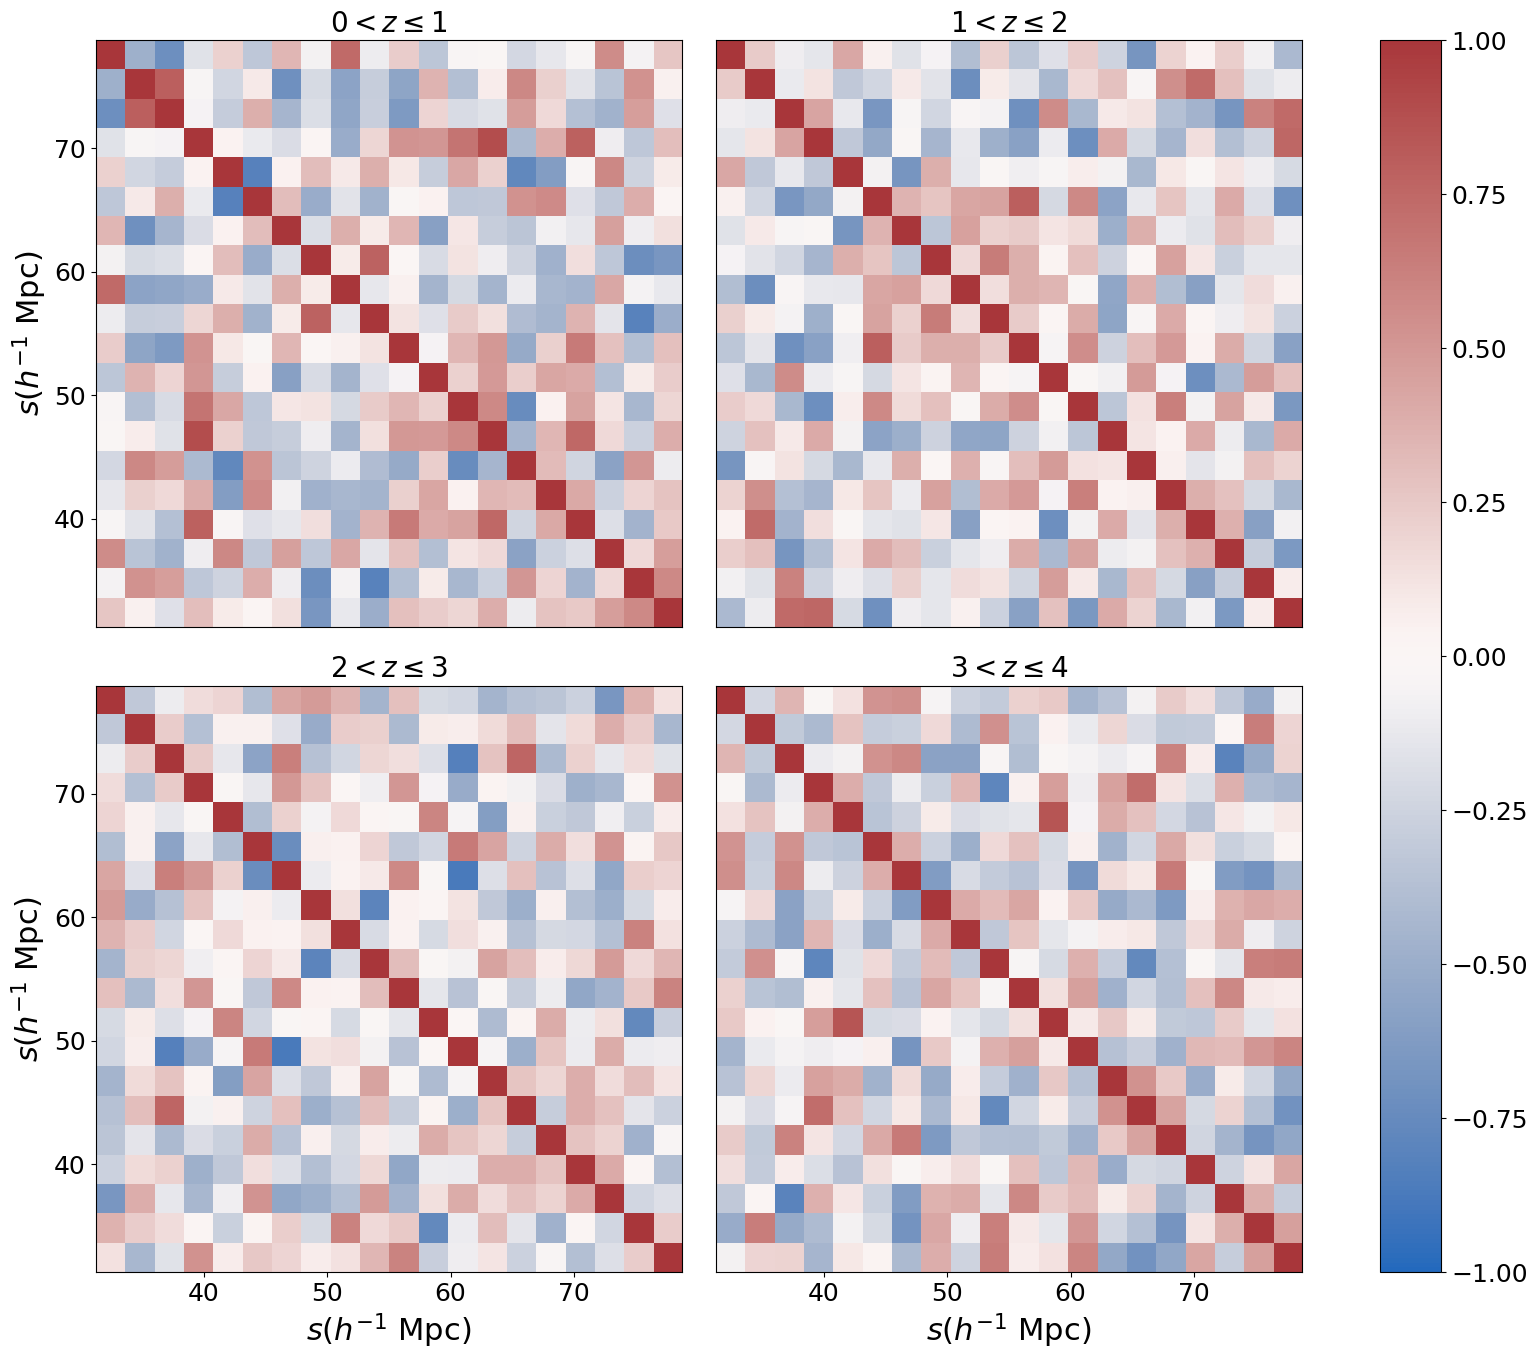

In [22]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.1)
axes = []
for zbin in zbin_array[:-1]:
    
    ax1 = fig.add_subplot(gs[int(zbin)])
    
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_z{}_N{}_planck20.npy'.format(G_hi, rmin, rmax, nbins, zbin, N))
    matrix = np.corrcoef(C)
    image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
    print(image.get_clim())
    if zbin>1:
        ax1.set_xlabel('$s (h^{-1}$ Mpc)')
    else:
        ax1.set_xticks([])
    if zbin %2 == 0:
        ax1.set_ylabel('$s (h^{-1}$ Mpc)')
    else:
        ax1.set_yticks([])
    ax1.set_title('${:.0f}<z \leq{:.0f}$'.format(zbin, zbin+1))
    axes.append(ax1)
    
fig.colorbar(image, ax = axes)
plt.show()